# Mərhələ 1: Datanın Anlaşılması və Təmizlənməsi

## Məqsədlər

Bu mərhələdə siz:

1. House Prices datasetinin strukturunu yükləyib anlayacaqsınız
2. Təkrarlanan (dublikat) yazıları müəyyən edib idarə edəcəksiniz
3. Data tiplərini təhlil edib xüsusiyyətləri (feature-ləri) kateqoriyalara ayıracaqsınız
4. Çatışmayan dəyərləri müəyyən edib idarə edəcəksiniz
5. Kənar qiymətləri (outlier) aşkar edib idarə edəcəksiniz
6. Sonrakı emal üçün təmiz baza dataset yaradacaqsınız

## Təlimatlar

Hər tapşırığı ardıcıllıqla yerinə yetirin. Müşahidə və qərarlarınızı markdown xanalarında sənədləşdirin.

---
## Tapşırıq 1: Kitabxanaları İmport Et

Data təmizlənməsi üçün lazım olan kitabxanaları import edin.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

# Set display options for better readability
pd.set_option('display.max_columns' , None)
pd.set_option('display.max_rows' , 100)

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Tapşırıq 2: Dataseti Yüklə

Təlim datasetini yükləyin və əsas məlumatları göstərin.

**Cavablandırılmalı suallar:**
- Datasetdə neçə müşahidə (sətir) var?
- Neçə xüsusiyyət (sütun) mövcuddur?
- Proqnozlaşdırmaq istədiyimiz hədəf dəyişən hansıdır?

In [25]:
# TODO: 'train.csv' faylından təlim datasını pd.read_csv() ilə yüklə
# Onu 'df' adlı dəyişəndə saxla
df = pd.read_csv(filepath_or_buffer="train.csv")
print("Success")

print(df.shape)

print(df.shape[0])
print(df.shape[1])
# TODO: Aşağıdakı məlumatları çap et:
# - Uğur mesajı
# - Datasetin ölçüsü (ipucu: df.shape istifadə et)
# - Müşahidələrin sayı (ipucu: df.shape[0] sətirlərin sayını verir)
# - Xüsusiyyətlərin sayı (ipucu: df.shape[1] sütunların sayını verir)

Success
(1460, 81)
1460
81


In [26]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [27]:
# TODO: Datasetin ilk 5 sətrini göstər
# DataFrame üzərində .head() metodundan istifadə et

In [28]:
# TODO: .info() metodu ilə dataset haqqında məlumat göstər
# Bu göstərir: data tiplərini, boş olmayan dəyərlərin sayını və yaddaş istifadəsini
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

### Müşahidələriniz:

Müşahidələrinizi buraya yazın:
- Ümumi sətir sayı: 
- Ümumi sütun sayı: 
- Hədəf dəyişən: 
- Diqqətçəkən xüsusiyyətlər: 

---
## Tapşırıq 3: Təkrarlanan Sətirləri Yoxla

Datasetdə təkrarlanan (dublikat) müşahidələrin olub-olmadığını müəyyən edin.

In [29]:
# TODO: Datasetdə təkrarlanan sətirləri yoxla
# - Dublikatları tapmaq üçün df.duplicated() istifadə et
# - Onları saymaq üçün .sum() istifadə et
# - Mesajı və sayı çap et

df.duplicated().sum()

# TODO: Dublikatlar varsa (say > 0), onları göstər
# - Bütün təkrarlanan sətirləri göstərmək üçün df[df.duplicated(keep=False)] istifadə et
# - keep=False bütün dublikatları True kimi işarələyir (yalnız ilk/son təkrarı deyil)

df[df.duplicated(keep=False)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


**Tələb olunan addım:**

Dublikatlar varsa, aşağıdakılardan birini seçin:
- Onları silin (tam eyni sətirlərdirsə)
- Əlavə araşdırma aparın (oxşar, lakin qanuni müxtəlif əmlaklar ola bilərsə)

Qərarınızı sənədləşdirin və aşağıda tətbiq edin.

In [30]:
# xeyr. tamamilə fərqli sətirlərdir. duplicate(eyni) sətirlər mövcud deyil.

---
## Tapşırıq 4: Xüsusiyyət Tiplərini Müəyyən Et

Xüsusiyyətləri say (numerik) və kateqorial tiplərə ayırın.

**Qeyd:** Bəzi say xüsusiyyətləri əslində kateqoriyaları ifadə edə bilər (məsələn, MSSubClass). Bunları müəyyən etmək üçün data təsviri faylından istifadə edin.

In [31]:
# TODO: Kateqorial və say sütunlarının siyahılarını yarat
# - Sütunları dtype-a görə süzmək üçün list comprehension istifadə et
# - Kateqorial: df[col].dtype == 'str'
# - Say (numerik): df[col].dtype != 'str'

categorical = [col for col in df.columns if df[col].dtype == 'str']
numeric = [col for col in df.columns if df[col].dtype != 'str']

#! select_dtypes(include='number') numeric deyerleri cixardir funksiya kimide isdifade ede bilerik


# TODO: Aşağıdakıları çap et:
# - Kateqorial sütunların sayı
# - Say sütunlarının sayı
# - Kateqorial sütun adlarının siyahısı
# - Say sütun adlarının siyahısı

print("Kateqorial sütunların sayı:", len(categorical))
print("Say sütunlarının sayı:", len(numeric))

print("Kateqorial sütunlar:", categorical)
print("Say sütunları:", numeric)


Kateqorial sütunların sayı: 43
Say sütunlarının sayı: 38
Kateqorial sütunlar: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Say sütunları: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbv

In [32]:
# TODO: Hər kateqorial sütundakı unikal dəyərləri təhlil et
# - Hər sütun üzrə unikal dəyərləri saymaq üçün .nunique() istifadə et
# - Ən yüksək unikal dəyər sayı olanları əvvəl göstərmək üçün .sort_values(ascending=False) istifadə et
# İpucu: df[cat_col].nunique().sort_values(ascending=False)

unique_counts = df[categorical].nunique().sort_values(ascending=False)
unique_counts

Neighborhood     25
Exterior2nd      16
Exterior1st      15
Condition1        9
SaleType          9
HouseStyle        8
RoofMatl          8
Condition2        8
Functional        7
BsmtFinType2      6
RoofStyle         6
BsmtFinType1      6
SaleCondition     6
Heating           6
Foundation        6
GarageType        6
ExterCond         5
LotConfig         5
MSZoning          5
GarageCond        5
GarageQual        5
HeatingQC         5
Electrical        5
BldgType          5
FireplaceQu       5
LandContour       4
LotShape          4
KitchenQual       4
MiscFeature       4
Fence             4
BsmtCond          4
ExterQual         4
BsmtExposure      4
BsmtQual          4
LandSlope         3
PoolQC            3
GarageFinish      3
PavedDrive        3
MasVnrType        3
Utilities         2
Alley             2
Street            2
CentralAir        2
dtype: int64

---
## Tapşırıq 5: Çatışmayan Dəyərləri Təhlil Et

Hansı xüsusiyyətlərdə çatışmayan dəyərlərin olduğunu müəyyən edin və çatışmayan datanın faizini hesablayın.

In [33]:
# TODO: Hər sütun üzrə çatışmayan dəyərləri hesabla
# - Çatışmayan dəyərləri saymaq üçün df.isnull().sum() istifadə et
# - Faizi hesabla: (missing_count / total_rows) * 100
# - 2 onluq işarəyə yuvarlaqlaşdır

missing_count = df.isna().sum()
total_rows = len(df)
missing_percent = (missing_count / len(df)) * 100 
missing_percent = missing_percent.round(2)

# TODO: Aşağıdakı sütunları olan DataFrame yarat: 'Column', 'Missing_Count', 'Missing_Percentage'

missing_summary = pd.DataFrame({
    "Column" : df.columns,
    "Missing_count" : missing_count.values,
    "missing_percentage" : missing_percent.values
})

# TODO: Yalnız çatışmayan dəyəri olan sütunları göstərmək üçün süz (Missing_Count > 0)
# - Missing_Percentage üzrə azalan sıra ilə sırala
# - İndeksi sıfırla

missing_summary = missing_summary[missing_summary['Missing_count'] > 0]
missing_summary = missing_summary.sort_values(by='missing_percentage',ascending=False)

#! drop= true etmeyende index adli lazimsiz sutun yaradir bu bize lazim deyil 

missing_summary = missing_summary.reset_index(drop=True)

# TODO: Xülasəni çap et
# - Çatışmayan dəyəri olan xüsusiyyətlərin sayı
# - Çatışmayan dəyərlərin xülasə DataFrame-i

missing_features_count = len(missing_summary)
print("Çatışmayan dəyəri olan xüsusiyyətlərin sayı:", missing_features_count)
print("\nÇatışmayan dəyərlərin xülasəsi:")
print(missing_summary)

Çatışmayan dəyəri olan xüsusiyyətlərin sayı: 19

Çatışmayan dəyərlərin xülasəsi:
          Column  Missing_count  missing_percentage
0         PoolQC           1453               99.52
1    MiscFeature           1406               96.30
2          Alley           1369               93.77
3          Fence           1179               80.75
4     MasVnrType            872               59.73
5    FireplaceQu            690               47.26
6    LotFrontage            259               17.74
7     GarageType             81                5.55
8    GarageYrBlt             81                5.55
9   GarageFinish             81                5.55
10    GarageQual             81                5.55
11    GarageCond             81                5.55
12  BsmtExposure             38                2.60
13  BsmtFinType2             38                2.60
14      BsmtQual             37                2.53
15      BsmtCond             37                2.53
16  BsmtFinType1             37    

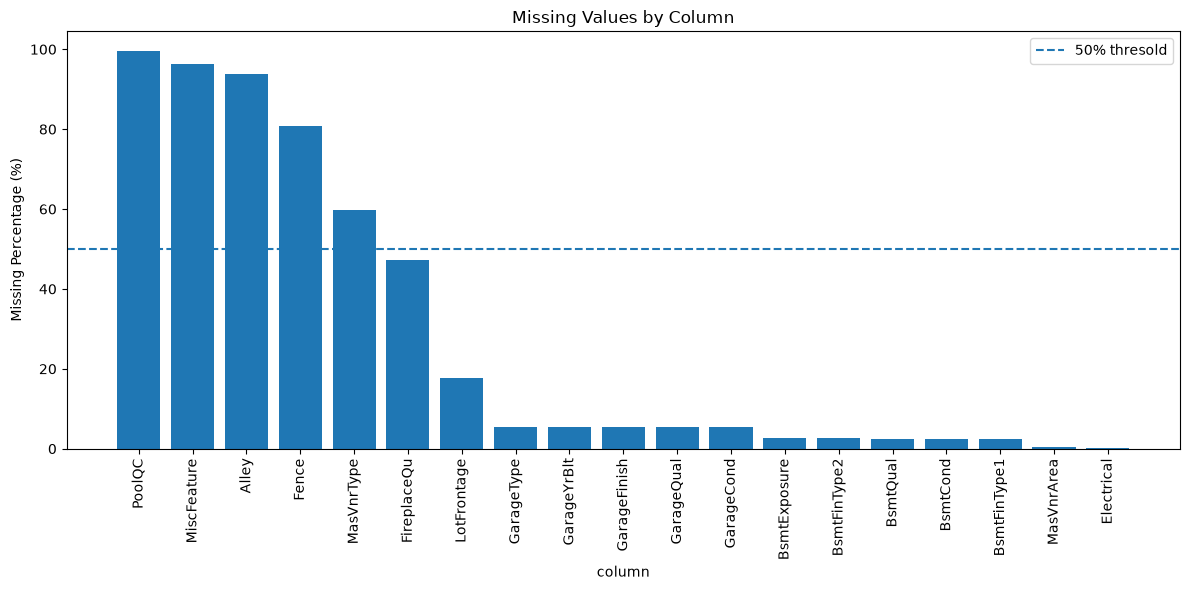

In [34]:
# TODO: Çatışmayan dəyərləri vizuallaşdırmaq üçün bar qrafiki yarat
# - Ölçüsü (12, 6) olan figure yarat
# - Column adları və Missing_Percentage ilə plt.bar() istifadə et
# - Oxunaqlılıq üçün x oxunun etiketlərini 90 dərəcə döndər
# - Etiketlər əlavə et: xlabel, ylabel, title
# - 50% həddində üfüqi xətt əlavə et (plt.axhline istifadə et)
# - Legend əlavə et və plt.tight_layout() istifadə et
# - plt.show() ilə 

plt.figure(figsize=(12, 6))

plt.bar(missing_summary['Column'] , missing_summary['missing_percentage'])
plt.xticks(rotation = 90)
plt.xlabel("column")
plt.ylabel('Missing Percentage (%)')
plt.title('Missing Values by Column')

plt.axhline(
    y = 50 , 
    linestyle = '--' , 
    label = "50% thresold"
)

plt.legend()

plt.tight_layout()

plt.show()

---
## Tapşırıq 6: Çatışmayan Dəyərləri İdarə Et

Çatışmayan dəyərlərin idarə olunması üçün strategiya hazırlayın. Aşağıdakıları nəzərə alın:

1. **Yüksək çatışma faizi (>50%):** Xüsusiyyəti silməyi düşünün
2. **Orta çatışma faizi (15-50%):** Doldurun (impute) və ya işarələyin (flag)
3. **Aşağı çatışma faizi (<15%):** Xüsusiyyətin tipinə uyğun doldurun
4. **Dizayna görə çatışan dəyərlər:** Bəzi xüsusiyyətlər əmlakda həmin element olmadığı üçün çatışmayabilir (məsələn, hovuz yoxdur, qaraj yoxdur). data_description.txt faylına baxın

**Strategiya qaydaları:**
- Kateqorial üçün: Moddan istifadə edin və ya 'None'/'Missing' kateqoriyası yaradın
- Say üçün: Orta (mean), median və ya proqnoz əsaslı doldurma istifadə edin
- Xüsusiyyətin əhəmiyyətini nəzərə alın (data_description.txt faylını oxuyun)

### Addım 6.1: Silinəcək Xüsusiyyətləri Müəyyən Et

Çatışma faizi çox yüksək olan və az dəyər verən xüsusiyyətləri sadalayın.

In [35]:
# TODO: Silinəcək xüsusiyyətlərin siyahısını yarat
# - Çatışmayan dəyərləri >50% olan xüsusiyyətləri nəzərə al
# - Əhəmiyyəti aşağı olan xüsusiyyətləri nəzərə al (data_description.txt faylını yoxla)
# Nümunə: features_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']

# Boş siyahı yarat
features_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']  # Təhlilinə əsasən xüsusiyyət adlarını əlavə et

# TODO: Silinən hər xüsusiyyət üçün səbəbi sənədləşdir
# features_to_drop siyahısı üzərində dövr et və hər birinin niyə silindiyini çap et

drop_reasons = {
    'PoolQC': 'Çox yüksək sayda çatışmayan dəyər var və NA hovuzun olmadığını göstərir.',
    'MiscFeature': 'Çox yüksək sayda çatışmayan dəyər var və NA əlavə xüsusiyyətin olmadığını göstərir.',
    'Alley': 'Çox yüksək sayda çatışmayan dəyər var və NA küçə arxası girişinin olmadığını göstərir.',
    'Fence': 'Çox yüksək sayda çatışmayan dəyər var və NA hasarın olmadığını göstərir.'
}

for feature in features_to_drop:
    print(f"{feature}: {drop_reasons[feature]}")


PoolQC: Çox yüksək sayda çatışmayan dəyər var və NA hovuzun olmadığını göstərir.
MiscFeature: Çox yüksək sayda çatışmayan dəyər var və NA əlavə xüsusiyyətin olmadığını göstərir.
Alley: Çox yüksək sayda çatışmayan dəyər var və NA küçə arxası girişinin olmadığını göstərir.
Fence: Çox yüksək sayda çatışmayan dəyər var və NA hasarın olmadığını göstərir.


### Addım 6.2: Kateqorial Çatışmayan Dəyərləri İdarə Et

Çatışmayan dəyərləri olan kateqorial xüsusiyyətlər üçün doldurma strategiyasını seçin.

In [36]:
# TODO: DataFrame-in işçi surətini yarat
df_clean = df.copy()

# TODO: Seçilmiş xüsusiyyətləri sil (features_to_drop siyahında varsa)
# - Siyahı boş deyilsə df.drop(columns=features_to_drop) istifadə et
# - Neçə xüsusiyyətin silindiyini çap et

if features_to_drop:
    df_clean = df_clean.drop(columns=features_to_drop)
    print(f"{len(features_to_drop)} xüsusiyyət silindi.")
else:
    print("Silinəcək xüsusiyyət yoxdur.")


# TODO: Kateqorial çatışmayan dəyərləri idarə et
# Strategiya 1: Çatışma yoxluq deməkdirsə, 'None' ilə doldur
#   Nümunə: df_clean['FeatureName'].fillna('None', inplace=True)

none_features = [
    'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
]

for col in none_features:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("Missing") 

#
# Strategiya 2: Çatışma təsadüfidirsə, mod ilə doldur
#   Nümunə: df_clean['FeatureName'].fillna(df_clean['FeatureName'].mode()[0], inplace=True)
#
# Hər xüsusiyyət üçün hansı strategiyanı seçəcəyini müəyyən etmək üçün data_description.txt faylına bax

# Electrical — hər evdə mütləq var, cəmi 1 xana boşdur → real çatışma
df_clean['Electrical'] = df_clean['Electrical'].fillna(df_clean['Electrical'].mode()[0])


4 xüsusiyyət silindi.


### Addım 6.3: Say Xüsusiyyətlərindəki Çatışmayan Dəyərləri İdarə Et

Çatışmayan dəyərləri olan say xüsusiyyətləri üçün uyğun doldurma üsulunu seçin.

In [37]:
# TODO: Say (numerik) çatışmayan dəyərləri idarə et
# Xüsusiyyətə uyğun strategiya seç:
#
# Seçim 1: Median ilə doldur (kənar qiymətlərə davamlıdır)
#   Nümunə: df_clean['LotFrontage'].fillna(df_clean['LotFrontage'].median(), inplace=True)
#
# Seçim 2: Orta (mean) ilə doldur (data normal paylanıbsa)
#   Nümunə: df_clean['FeatureName'].fillna(df_clean['FeatureName'].mean(), inplace=True)
#
# Seçim 3: 0 ilə doldur (çatışma həmin xüsusiyyətin olmaması deməkdirsə)
#   Nümunə: df_clean['GarageYrBlt'].fillna(0, inplace=True)
#
# Çatışmayan dəyəri olan hər say xüsusiyyətini təhlil et və uyğun strategiyanı tətbiq et

# 0 ilə doldur: obyekt yoxdursa, il/sahə də yoxdur
zero_features = ['GarageYrBlt', 'MasVnrArea']
df_clean[zero_features] = df_clean[zero_features].fillna(0)

# Median ilə doldur: küçə uzunluğu mütləq var, sadəcə qeyd olunmayıb
df_clean['LotFrontage'] = df_clean['LotFrontage'].fillna(df_clean['LotFrontage'].median())

print("Say xüsusiyyətləri dolduruldu.")


Say xüsusiyyətləri dolduruldu.


In [38]:
# TODO: Bütün çatışmayan dəyərlərin idarə olunduğunu yoxla
# - Qalan çatışmayan dəyərlərin ümumi sayını hesabla: df_clean.isnull().sum().sum()

remaining = df_clean.isna().sum().sum()
# - Sayı çap et

print("Qalan çatışmayan dəyərlərin sayı:", remaining)
# - Hələ də qalanlar varsa, hansı xüsusiyyətlərdə çatışmanın qaldığını çap et

if remaining > 0 :
    left = df_clean.isnull().sum()
    print(left[left > 0])
else:
    print("Bütün çatışmayan dəyərlər idarə olundu!") 

Qalan çatışmayan dəyərlərin sayı: 0
Bütün çatışmayan dəyərlər idarə olundu!


---
## Tapşırıq 7: Kənar Qiymətləri Aşkar Et və Təhlil Et

Əsas say xüsusiyyətlərindəki kənar qiymətləri (outlier) müəyyən etmək üçün box plot-lardan və IQR üsulundan istifadə edin.

In [39]:
# TODO: Kənar qiymət təhlili üçün əsas say xüsusiyyətlərini seç
# Ölçü, sahə və qiymətlə bağlı xüsusiyyətlərə diqqət yetir
# Nümunə siyahı: ['LotArea', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'SalePrice']

key_numeric_features = ['LotArea', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'SalePrice']
key_numeric_features = [col for col in key_numeric_features if col in df_clean.columns]
print("Təhlil olunacaq xüsusiyyətlər:", key_numeric_features)
print("Sayı:", len(key_numeric_features))


# TODO: Yalnız df_clean-də mövcud olanları saxlamaq üçün süz
# List comprehension istifadə et: [col for col in key_numeric_features if col in df_clean.columns]

Təhlil olunacaq xüsusiyyətlər: ['LotArea', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'SalePrice']
Sayı: 6


C:\Users\Elton\AppData\Local\Temp\ipykernel_23308\3839217303.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df_clean[col].dropna() , vert=False)
C:\Users\Elton\AppData\Local\Temp\ipykernel_23308\3839217303.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df_clean[col].dropna() , vert=False)
C:\Users\Elton\AppData\Local\Temp\ipykernel_23308\3839217303.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df_clean[col].dropna() , vert=False)
C:\Users\Elton\AppData\Local\Temp\ipykernel_23308\3839217303.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be remov

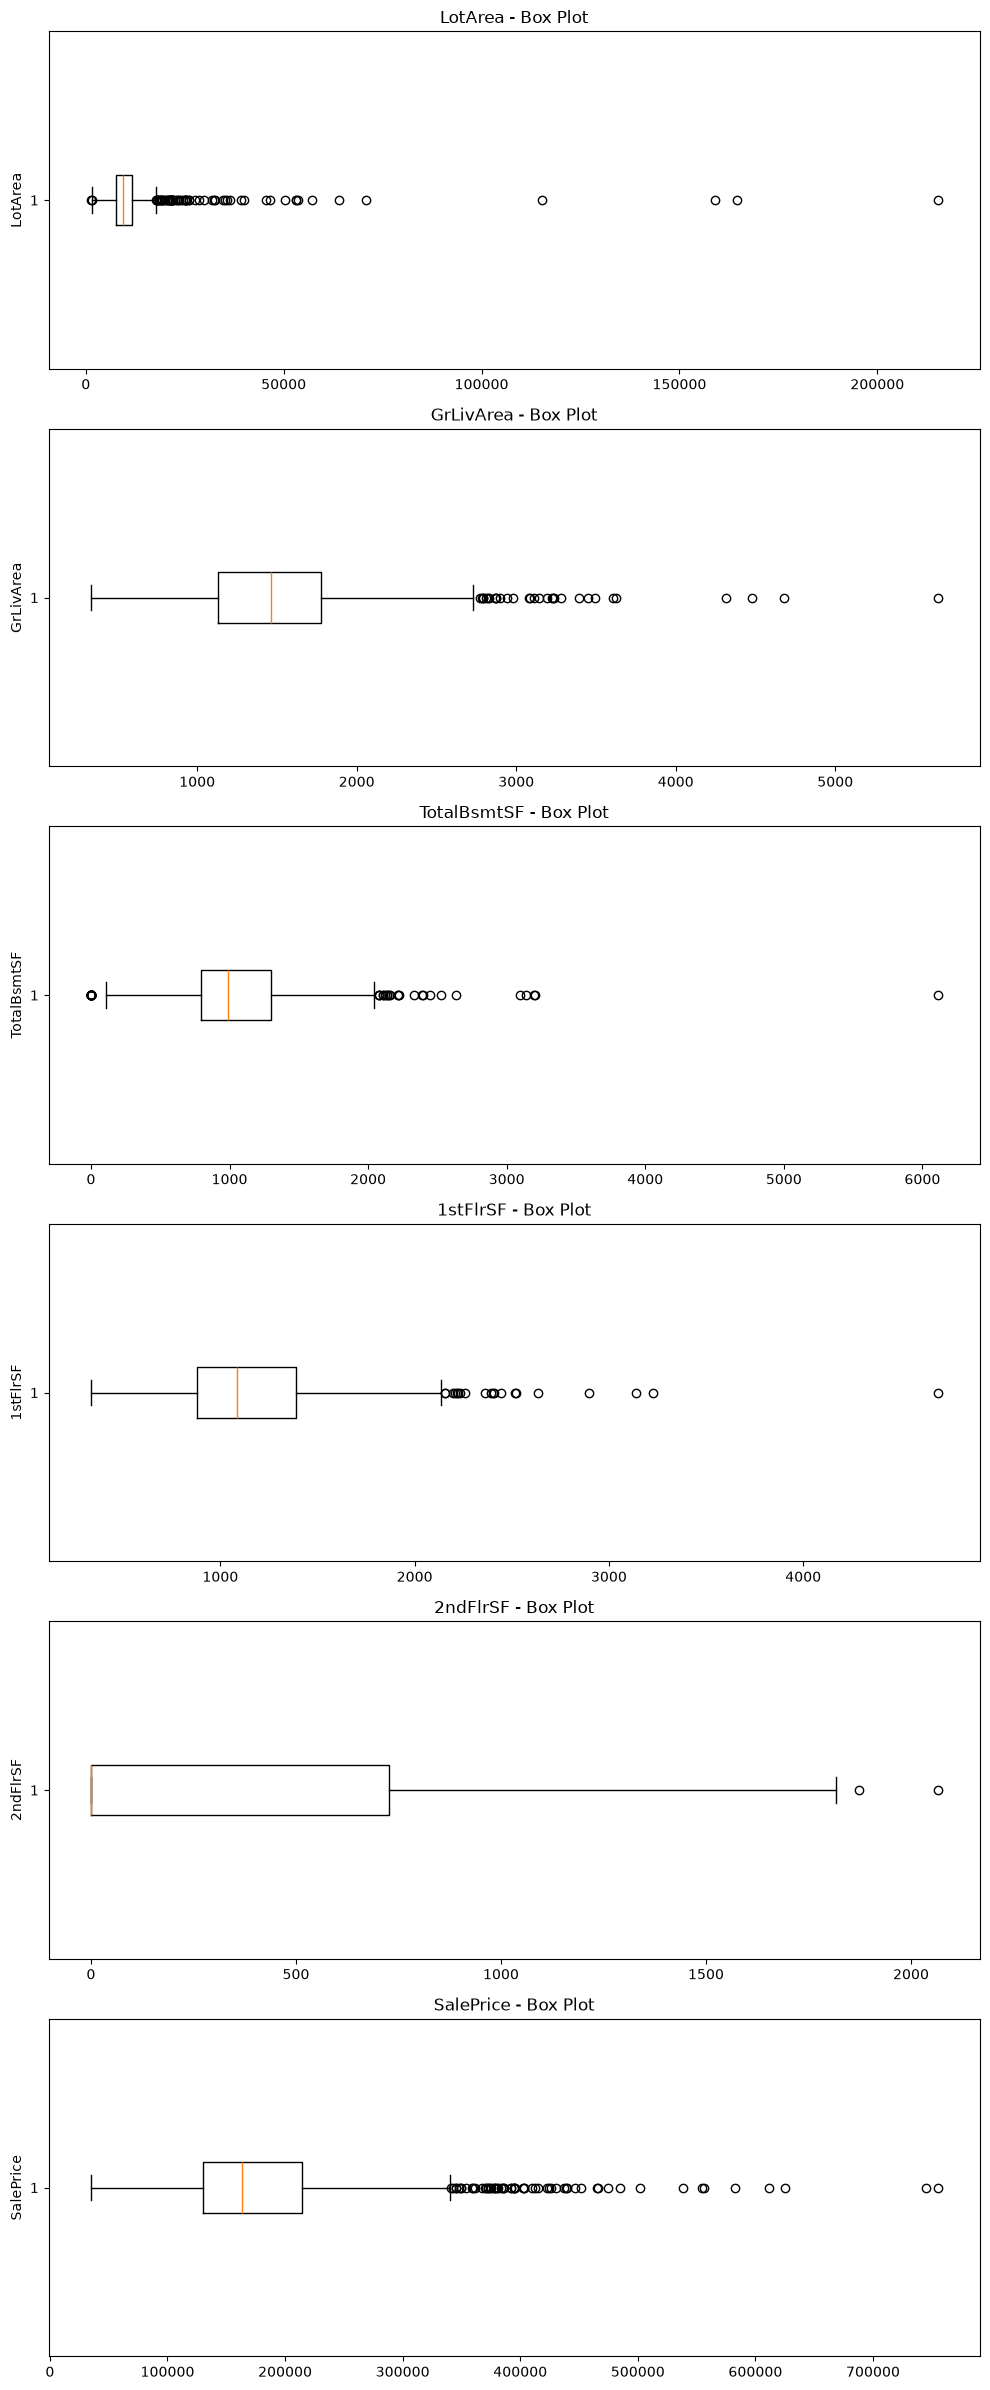

In [40]:
# TODO: Hər əsas say xüsusiyyəti üçün box plot-lar yarat
# - Subplot-lar yarat: fig, axes = plt.subplots(n_features, 1, figsize=(10, 4*n_features))
# - Yalnız 1 xüsusiyyət olduqda: axes-i siyahıya çevir
# - Xüsusiyyətlər üzərində dövr et və hər biri üçün üfüqi box plot yarat
#   - axes[i].boxplot(df_clean[col].dropna(), vert=False) istifadə et
#   - ylabel və title təyin et
# - plt.tight_layout() və plt.show() istifadə et

n_features  = len(key_numeric_features)
fig ,axes = plt.subplots(n_features , 1 , figsize = (10, 4 * n_features))

if n_features == 1 :
    axes = [axes]

for i, col in enumerate(key_numeric_features):
    axes[i].boxplot(df_clean[col].dropna() , vert=False)
    axes[i].set_ylabel(col)
    axes[i].set_title(f'{col} - Box Plot')
    
plt.tight_layout()
plt.show()

### Addım 7.1: IQR Üsulu ilə Kənar Qiymətləri Hesabla

Seçilmiş xüsusiyyətlər üçün kənar qiymətləri IQR üsulu ilə müəyyən edin.

In [41]:
# TODO: IQR üsulu ilə kənar qiymətləri aşkar edən funksiya yarat
# Funksiya bunları etməlidir:
# 1. np.percentile() ilə Q1 (25-ci percentil) və Q3 (75-ci percentil) hesabla
# 2. IQR = Q3 - Q1 hesabla
# 3. Sərhədləri hesabla: lower_bound = Q1 - 1.5 * IQR, upper_bound = Q3 + 1.5 * IQR
# 4. Kənar qiymətləri tap: dəyərlər < lower_bound VƏ YA dəyərlər > upper_bound
# 5. Qaytar: kənar qiymətlər dataframe-i, lower_bound, upper_bound

def detect_outliers_iqr(df , column):
    values = df[column].dropna()

    Q1 = np.percentile(values , 25)
    Q3 = np.percentile(values , 75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[ (df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# TODO: Funksiyanı hər əsas say xüsusiyyətinə tətbiq et
# - key_numeric_features üzərində dövr et
# - Sütun adını, sərhədləri və tapılan kənar qiymətlərin sayını çap et

for col in key_numeric_features:
    outliers , lower , upper = detect_outliers_iqr(df_clean , col)
    print(f"{col}:")
    print(f"Alt sərhəd: {lower:.2f}")
    print(f"Üst sərhəd: {upper:.2f}")
    print(f"Kənar qiymətlərin sayı: {len(outliers)} ({len(outliers) / len(df_clean) * 100:.2f}%)")
    print()

LotArea:
Alt sərhəd: 1481.50
Üst sərhəd: 17673.50
Kənar qiymətlərin sayı: 69 (4.73%)

GrLivArea:
Alt sərhəd: 158.62
Üst sərhəd: 2747.62
Kənar qiymətlərin sayı: 31 (2.12%)

TotalBsmtSF:
Alt sərhəd: 42.00
Üst sərhəd: 2052.00
Kənar qiymətlərin sayı: 61 (4.18%)

1stFlrSF:
Alt sərhəd: 118.12
Üst sərhəd: 2155.12
Kənar qiymətlərin sayı: 20 (1.37%)

2ndFlrSF:
Alt sərhəd: -1092.00
Üst sərhəd: 1820.00
Kənar qiymətlərin sayı: 2 (0.14%)

SalePrice:
Alt sərhəd: 3937.50
Üst sərhəd: 340037.50
Kənar qiymətlərin sayı: 61 (4.18%)



### Addım 7.2: Kənar Qiymətlər Barədə Qərar

**Vacib:** Bütün kənar qiymətlər silinməməlidir. Aşağıdakıları nəzərə alın:
- Bunlar data daxiletmə xətalarıdır, yoxsa qanuni ekstremal dəyərlər?
- Bunlar nadir, lakin etibarlı əmlakları (məsələn, malikanələr, unikal evlər) təmsil edirmi?
- Onları silmək modelin performansını yaxşılaşdıracaq, yoxsa pisləşdirəcək?

Kənar qiymətlərlə bağlı qərarınızı sənədləşdirin.

In [42]:
# Examine extreme outliers in detail
# Example: Look at properties with very large living area
# extreme_area = df_clean[df_clean['GrLivArea'] > 4000]
# print(extreme_area[['GrLivArea', 'SalePrice', 'OverallQual', 'OverallCond']])

# Your analysis here
extreme_area = df_clean[df_clean['GrLivArea'] > 4000]

print(
    extreme_area[
        [
            'GrLivArea',
            'SalePrice',
            'OverallQual',
            'OverallCond',
            'YearBuilt',
            'Neighborhood',
            'GarageCars',
            'TotalBsmtSF'
        ]
    ]
)
print("-------------------------------------")

suspicious = df_clean.loc[
    [523, 1298]
]

print(
    suspicious[
        [
            'GrLivArea',
            'SalePrice',
            'OverallQual',
            'OverallCond',
            'YearBuilt',
            'Neighborhood',
            'TotalBsmtSF',
            '1stFlrSF',
            '2ndFlrSF',
            'GarageArea',
            'FullBath',
            'BedroomAbvGr',
            'TotRmsAbvGrd'
        ]
    ]
)

      GrLivArea  SalePrice  OverallQual  OverallCond  YearBuilt Neighborhood  \
523        4676     184750           10            5       2007      Edwards   
691        4316     755000           10            6       1994      NoRidge   
1182       4476     745000           10            5       1996      NoRidge   
1298       5642     160000           10            5       2008      Edwards   

      GarageCars  TotalBsmtSF  
523            3         3138  
691            3         2444  
1182           3         2396  
1298           2         6110  
-------------------------------------
      GrLivArea  SalePrice  OverallQual  OverallCond  YearBuilt Neighborhood  \
523        4676     184750           10            5       2007      Edwards   
1298       5642     160000           10            5       2008      Edwards   

      TotalBsmtSF  1stFlrSF  2ndFlrSF  GarageArea  FullBath  BedroomAbvGr  \
523          3138      3138      1538         884         3             3   
1298  

GrLivArea > 4000 olan evlərin sayı: 4
        Id  GrLivArea  TotalBsmtSF  SalePrice  OverallQual  OverallCond  \
523    524       4676         3138     184750           10            5   
691    692       4316         2444     755000           10            6   
1182  1183       4476         2396     745000           10            5   
1298  1299       5642         6110     160000           10            5   

     SaleCondition  
523        Partial  
691         Normal  
1182       Abnorml  
1298       Partial  


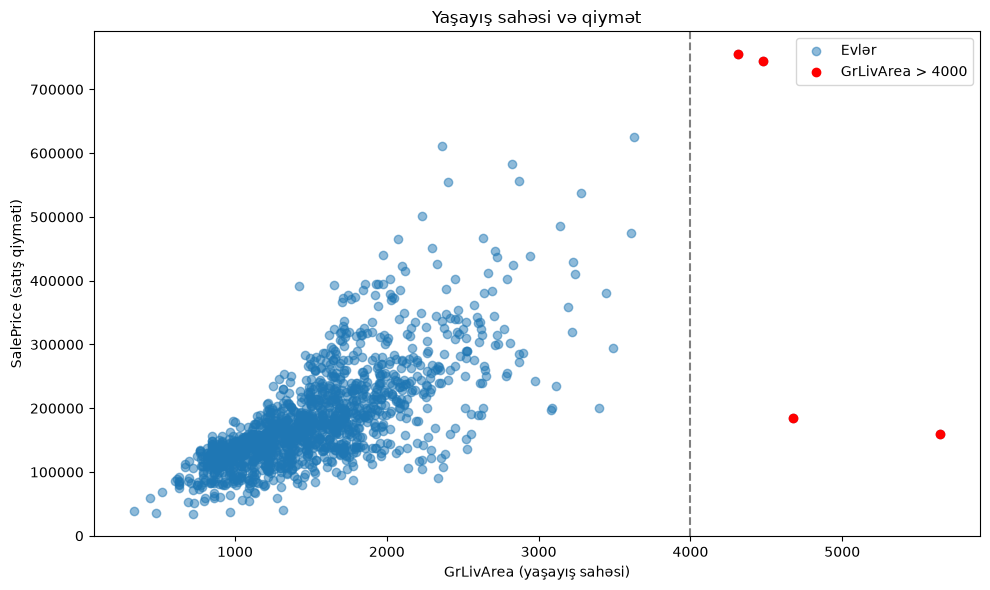

------------------------------------
------------------------------------
------------------------------------
Silinən ev sayı: 2
        Id  GrLivArea  SalePrice  OverallQual SaleCondition
523    524       4676     184750           10       Partial
1298  1299       5642     160000           10       Partial

Əvvəl: (1460, 77)
Sonra: (1458, 77)


In [43]:
# TODO: Müəyyən kənar qiymətləri silməyin-silməməyin qərarını ver
# Vacib: Bütün kənar qiymətlər silinməməlidir!
# 
# Nəzərə al:
# - Bunlar data daxiletmə xətalarıdır, yoxsa qanuni ekstremal dəyərlər?
# - Bunlar nadir, lakin etibarlı əmlakları təmsil edirmi (malikanələr, unikal evlər)?
# 
# Kənar qiymətləri silirsənsə, əsaslandırmanı sənədləşdir
# Nümunə: df_clean = df_clean[df_clean['GrLivArea'] < 4000]

# 1. Çox böyük yaşayış sahəsi olan evlərə yaxından bax
extreme_area = df_clean[df_clean['GrLivArea'] > 4000]
print("GrLivArea > 4000 olan evlərin sayı:", len(extreme_area))
print(extreme_area[['Id', 'GrLivArea', 'TotalBsmtSF', 'SalePrice',
                    'OverallQual', 'OverallCond', 'SaleCondition']])

# 2. Sahə ilə qiymət arasındakı əlaqəyə bax
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['GrLivArea'], df_clean['SalePrice'], alpha=0.5, label='Evlər')
plt.scatter(extreme_area['GrLivArea'], extreme_area['SalePrice'],
            color='red', label='GrLivArea > 4000')
plt.axvline(x=4000, linestyle='--', color='gray')
plt.xlabel('GrLivArea (yaşayış sahəsi)')
plt.ylabel('SalePrice (satış qiyməti)')
plt.title('Yaşayış sahəsi və qiymət')
plt.legend()
plt.tight_layout()
plt.show()

print("------------------------------------")
print("------------------------------------")
print("------------------------------------")
# Qərar: sahəsi çox böyük, amma qiyməti aşağı olan evlər məntiqsizdir → sil
# Sahəsi çox böyük və qiyməti də yüksək olan evlər real malikanələrdir → saxla

original_shape = df_clean.shape

mask = (df_clean['GrLivArea'] > 4000) & (df_clean['SalePrice'] < 300000)
removed = df_clean[mask]

print("Silinən ev sayı:", len(removed))
print(removed[['Id', 'GrLivArea', 'SalePrice', 'OverallQual', 'SaleCondition']])

df_clean = df_clean[~mask].reset_index(drop=True)

print("\nƏvvəl:", original_shape)
print("Sonra:", df_clean.shape)

---
## Tapşırıq 8: Yekun Data Yoxlaması

Təmizlənmiş datasetin növbəti mərhələyə hazır olduğunu yoxlayın.

In [44]:
# TODO: Yekun dataset xülasəsini çap et
# Orijinal ilə təmizlənmişi müqayisə et:
# - Orijinal ölçü ilə təmizlənmiş ölçü
# - Silinmiş sətirlərin sayı
# - Silinmiş sütunların sayı
# - Qalan çatışmayan dəyərlərin sayı
# - Data tiplərinin value_counts nəticəsi

print("Orijinal ölçü: ", df.shape)
print("Təmizlənmiş ölçü: ", df_clean.shape)

rows_removed = df.shape[0] - df_clean.shape[0]
cols_removed = df.shape[1] - df_clean.shape[1]
print("\nSilinmiş sətirlərin sayı: ", rows_removed)
print("Silinmiş sütunların sayı: ", cols_removed)

print("Qalan çatışmayan dəyərlərin sayı:", df_clean.isnull().sum().sum())

retained = df_clean.shape[0] / df.shape[0] * 100
print(f"Saxlanılan sətirlər: {retained:.2f}%")

print(df_clean.dtypes.value_counts())

Orijinal ölçü:  (1460, 81)
Təmizlənmiş ölçü:  (1458, 77)

Silinmiş sətirlərin sayı:  2
Silinmiş sütunların sayı:  4
Qalan çatışmayan dəyərlərin sayı: 0
Saxlanılan sətirlər: 99.86%
str        39
int64      35
float64     3
Name: count, dtype: int64


In [45]:
# TODO: Təmizlənmiş dataseti CSV kimi yadda saxla
# - df_clean.to_csv('train_cleaned.csv', index=False) istifadə et
# - Təsdiq mesajı çap et

df_clean.to_csv('train_cleaned.csv', index=False)

---
## Xülasə və Düşüncə

### Nələri Tamamladınız:

1. House Prices datasetinin strukturunu yüklədiniz və anladınız
2. Təkrarlanan yazıları müəyyən edib idarə etdiniz
3. Xüsusiyyətləri say və kateqorial tiplərə ayırdınız
4. Çatışmayan dəyərləri sistemli şəkildə təhlil edib idarə etdiniz
5. Kənar qiymətləri IQR üsulu ilə aşkar edib idarə etdiniz
6. Təmiz baza dataset yaratdınız

### Düşüncə üçün Əsas Suallar:

1. Təmizləmədən sonra orijinal datanın neçə faizi saxlanıldı?
2. Hansı xüsusiyyətlərdə ən çox data çatışmırdı və onları necə idarə etdiniz?
3. Çatışmayan datada hər hansı qanunauyğunluq müəyyən etdinizmi?
4. Hansı kənar qiymətləri saxlayacağınıza, hansıları siləcəyinizə necə qərar verdiniz?
5. Hansı çətinliklərlə qarşılaşdınız və onları necə həll etdiniz?

### Növbəti Addımlar:

**Mərhələ 2: Data Ön Emalı** hissəsinə keçin, burada siz:
- Kateqorial dəyişənləri kodlaşdıracaqsınız
- Say xüsusiyyətlərini miqyaslayacaqsınız
- Asimmetriyanı (skewness) idarə edəcəksiniz
- Datanı feature engineering üçün hazırlayacaqsınız